# Descenso de gradiente

El **descenso de gradiente** es un algoritmo de **optimización** fundamental en el aprendizaje automático, utilizado para encontrar los valores de los parámetros (coeficientes o pesos) de una función que minimizan una **función de costo**. En esencia, es un método iterativo que busca el mínimo local o global de una función diferenciable.

A continuación se detallan sus componentes y funcionamiento:

### Funcionamiento del Algoritmo
1.  **Inicialización:** El proceso comienza con valores iniciales para los coeficientes, que pueden ser cero o valores aleatorios pequeños.

2.  **Evaluación del costo:** Se calcula el error o "coste" de los valores actuales mediante una función de pérdida, que mide qué tan alejadas están las predicciones del modelo respecto a los valores reales.

3.  **Cálculo del gradiente:** Se calcula la **derivada** de la función de costo, la cual representa la pendiente de la función en ese punto específico. El gradiente indica la dirección del ascenso más pronunciado; por lo tanto, el algoritmo se mueve en la **dirección opuesta (negativa)** para descender hacia el mínimo.

4.  **Actualización de parámetros:** Los coeficientes se actualizan restando una fracción del gradiente. Esta fracción está determinada por un hiperparámetro crucial llamado **tasa de aprendizaje** (*learning rate*), que controla el tamaño del paso en cada iteración.

5.  **Repetición:** El proceso se repite hasta que el costo llega a cero o ya no se pueden lograr mejoras significativas.

### Tipos de Descenso de Gradiente
*   **Batch Gradient Descent (Por lotes):** Utiliza **todo el conjunto de datos** de entrenamiento para calcular el gradiente antes de realizar una sola actualización de los parámetros. Es preciso pero puede ser muy lento en conjuntos de datos masivos.

*   **Stochastic Gradient Descent (Estocástico - SGD):** Actualiza los parámetros inmediatamente después de procesar **cada instancia** de entrenamiento individual. Es mucho más rápido y puede ayudar a evitar mínimos locales mediocres gracias al "ruido" en sus actualizaciones, aunque su convergencia es más oscilatoria.

*   **Mini-batch Gradient Descent:** Un punto intermedio que actualiza los parámetros basándose en **pequeños subgrupos** de datos, combinando la eficiencia del SGD con la estabilidad del método por lotes.

### Consideraciones Clave
*   **Tasa de aprendizaje:** Si es demasiado pequeña, el algoritmo será extremadamente lento; si es demasiado grande, puede oscilar o incluso divergir, saltándose el mínimo.

*   **Mínimos locales y puntos de silla:** En funciones no convexas (comunes en redes neuronales profundas), el algoritmo puede quedar atrapado en un **mínimo local** (un valle que no es el más profundo) o ralentizarse en **puntos de silla**.

*   **Escalado de características:** El algoritmo converge más rápido si todas las variables de entrada están en una escala similar (por ejemplo, entre 0 y 1), evitando que la función de costo se deforme o alargue.

***

**Analogía:** Imagine a un **hombre con los ojos vendados** que intenta bajar desde la cima de una montaña hasta el fondo de un valle. No puede ver la topografía, pero puede sentir con sus pies la inclinación del terreno en su posición actual. Para llegar abajo, toma un paso en la dirección donde siente que la **pendiente desciende más abruptamente**. Si da pasos gigantes (tasa de aprendizaje alta), corre el riesgo de pasarse del fondo y empezar a subir por la ladera opuesta; si da pasos diminutos, tardará demasiado tiempo en llegar.

**Tasa de aprendizaje**

La tasa de aprendizaje (learning rate, $α$) en descenso de gradiente es el parámetro que controla el tamaño del paso que da el algoritmo al actualizar los parámetros del modelo en la dirección del gradiente negativo.

La tasa de aprendizaje controla la velocidad y estabilidad del entrenamiento.

- Demasiado alta → inestabilidad

- Demasiado baja → ineficiencia

- Bien elegida → aprendizaje eficiente

En términos prácticos:

Define qué tan rápido (y qué tan estable) aprende el modelo.


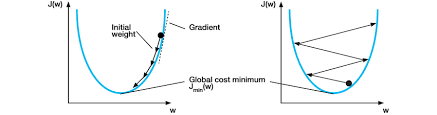

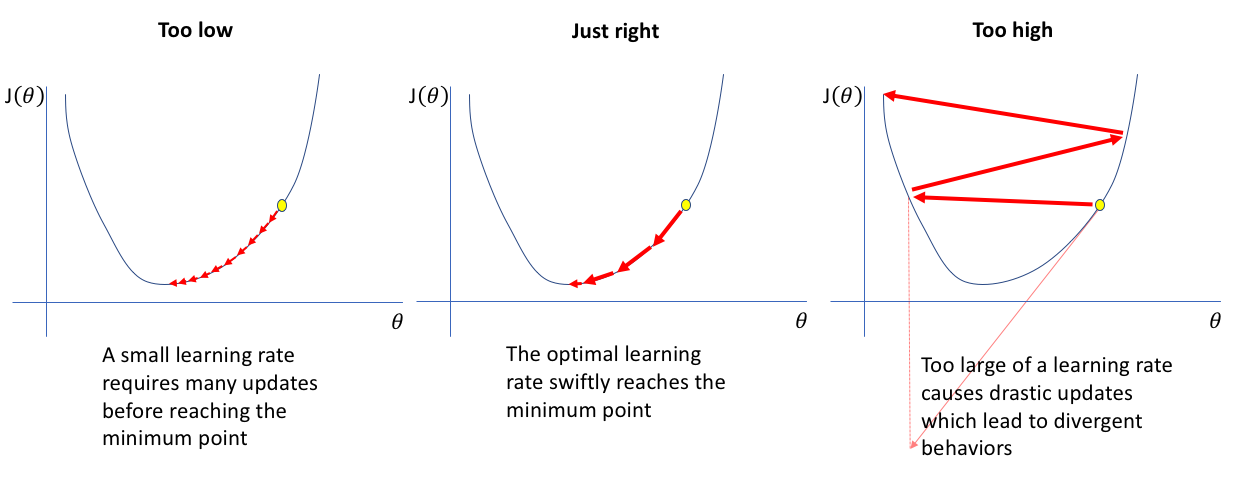

En la **práctica real**, el **descenso de gradiente** se utiliza como **mecanismo general de optimización** para **ajustar modelos paramétricos** cuando **no existe solución analítica cerrada** o cuando dicha solución es **computacionalmente inviable**. Su rol es transversal en *Machine Learning*, *Deep Learning* y *optimización aplicada*.


## 1️⃣ Problema real que resuelve

En términos prácticos, casi todo problema de modelamiento se reduce a:

> **Encontrar los parámetros que minimizan una función de error o pérdida.**

Formalmente:

$$
\min_{\boldsymbol{\theta}} J(\boldsymbol{\theta})
$$

Cuando:

* $J(\boldsymbol{\theta})$ es compleja
* el número de parámetros es grande
* los datos son masivos

➡️ **No es viable resolverlo con álgebra cerrada**

➡️ Se requiere un **método iterativo** → *Descenso de gradiente*

---

## 2️⃣ ¿Por qué no usar siempre la solución exacta?

Ejemplo: **regresión lineal**

| Enfoque               | Limitación práctica         |
| --------------------- | --------------------------- |
| OLS (ecuación normal) | Invertir matrices (O(n^3))  |
| Datos grandes         | No cabe en memoria          |
| Features > 100k       | Inviable computacionalmente |
| Streaming de datos    | No soportado                |
| Modelos no lineales   | No existe solución cerrada  |

📌 **Descenso de gradiente escala mejor** y es incremental.

---

## 3️⃣ Usos reales más comunes

### 🔹 1. Machine Learning clásico

Se usa para entrenar:

* Regresión lineal (datasets grandes)
* Regresión logística
* SVM (versión primal)
* Elastic Net / Ridge / Lasso
* PCA optimizado

📍 Ejemplo real:

> Modelos de **scoring crediticio** con millones de clientes y miles de variables.

---

### 🔹 2. Deep Learning (uso dominante)

Todo entrenamiento de redes neuronales se basa en:

* Descenso de gradiente
* Backpropagation (aplicación eficiente del gradiente)

📍 Ejemplos reales:

* Visión computacional (detección de tumores)
* NLP (chatbots, traducción automática)
* Sistemas de recomendación (Netflix, Spotify)

Sin descenso de gradiente → **no hay deep learning**.

---

### 🔹 3. Optimización con Big Data

Cuando los datos:

* No caben en memoria
* Llegan por streaming
* Cambian en el tiempo

Se usa:

* **Stochastic Gradient Descent (SGD)**
* **Mini-batch Gradient Descent**

📍 Ejemplo:

> Ajuste de modelos de fraude bancario **en tiempo casi real**.

---

## 4️⃣ Ejemplo concreto (industria)

### 🎯 Predicción de demanda energética

Variables:

* Temperatura
* Hora del día
* Historial de consumo
* Festivos

Características:

* Millones de registros
* Modelo no lineal
* Entrenamiento diario

📌 Solución real:

* Descenso de gradiente + mini-batch
* Entrenamiento distribuido (Spark / GPU)

---

## 5️⃣ ¿Por qué es tan importante en la práctica?

| Ventaja   | Impacto real                    |
| --------- | ------------------------------- |
| Escalable | Funciona con Big Data           |
| Iterativo | Soporta streaming               |
| Flexible  | Cualquier función diferenciable |
| General   | Base de casi todo ML            |
| Eficiente | Compatible con GPU              |

---

## 6️⃣ Variantes usadas en producción

En la práctica **no se usa el descenso de gradiente “puro”**, sino versiones optimizadas:

| Método        | Cuándo se usa         |
| ------------- | --------------------- |
| SGD           | Datos masivos         |
| Mini-batch GD | Deep learning         |
| Momentum      | Convergencia lenta    |
| RMSProp       | Gradientes inestables |
| Adam          | Estándar industrial   |

📌 **Adam** es hoy el *default* en producción.

---

## 7️⃣ Señal clara de uso real

Si un modelo cumple alguna de estas condiciones:

* > 100k parámetros
* Datos >1M filas
* Función no lineal
* Entrenamiento continuo

➡️ **Descenso de gradiente es la única opción viable**

---

## 8️⃣ Resumen ejecutivo

> **El descenso de gradiente se usa porque permite entrenar modelos reales, grandes y complejos, donde los métodos exactos no funcionan o no escalan.**

Es el **motor invisible** detrás de:

* IA moderna
* Deep learning
* Modelos predictivos industriales

---

## Ejemplo de descenso de gradiente para regresión lineal con 1 variable

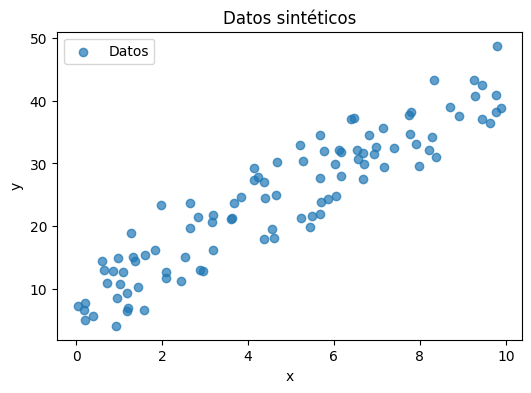

In [40]:
# Ejemplo autocontenido de Descenso de Gradiente para regresión lineal (1 variable)
# Genera datos sintéticos, aplica feature scaling, ejecuta gradient descent y muestra resultados.

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# 1) Generar datos sintéticos (y = a*x + b + ruido)
a_true = 3.5
b_true = 7.0
n = 100
x = np.random.uniform(0, 10, size=n)
y = a_true * x + b_true + np.random.normal(scale=4.0, size=n)


# 2) Visualizar datos
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.7, label='Datos')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Datos sintéticos')
plt.legend()
plt.show()


In [41]:

# 3) Preparar matrices (con bias) y escalar la característica
mu = x.mean()
sigma = x.std()
x_scaled = (x - mu) / sigma

X_scaled = np.vstack([np.ones(n), x_scaled]).T  # diseño: [1, x_scaled]
y_vec = y.reshape(-1, 1)

# 4) Funciones de costo y descenso de gradiente (vectorizado, batch)
def compute_cost(X, y, theta):
    """Calcula el costo de la regresión lineal.
    X: matriz de diseño (m x n)
    y: vector de salidas (m x 1)
    theta: parámetros (n x 1)
    Retorna: costo (escalar)
    """
    m = len(y)
    preds = X @ theta
    return (1/(2*m)) * np.sum((preds - y)**2)

def gradient_descent(X, y, theta, alpha, iters):
    """Realiza descenso de gradiente para minimizar el costo.
    X: matriz de diseño (m x n)
    y: vector de salidas (m x 1)
    theta: parámetros iniciales (n x 1)
    alpha: tasa de aprendizaje
    iters: número de iteraciones
    Retorna: theta optimizado, historial de costos
    """
    m = len(y)
    J_hist = np.zeros(iters)
    for i in range(iters):
        grad = (X.T @ (X @ theta - y)) / m
        theta = theta - alpha * grad
        J_hist[i] = compute_cost(X, y, theta)
    return theta, J_hist

# 5) Inicializar y ejecutar
theta_init = np.zeros((2,1))
alpha = 0.1     # tasa de aprendizaje (en espacio escalado puede ser mayor)
iters = 200

theta_scaled, J_hist = gradient_descent(X_scaled, y_vec, theta_init, alpha, iters)

# 6) Convertir parámetros al espacio original (no escalado)
theta0_s, theta1_s = theta_scaled.flatten()
theta1_orig = theta1_s / sigma
theta0_orig = theta0_s - (theta1_s * mu / sigma)

# 7) Comparación con la solución normal (closed-form) usando X original
X_orig = np.vstack([np.ones(n), x]).T
theta_normal = np.linalg.pinv(X_orig.T @ X_orig) @ X_orig.T @ y_vec
theta_normal = theta_normal.flatten()

# 8) Mostrar resultados
print(f"Parámetros reales:       a={a_true:.4f}, b={b_true:.4f}")
print(f"Gradient Descent (orig): a={theta1_orig:.4f}, b={theta0_orig:.4f}")
print(f"Normal Equation:         a={theta_normal[1]:.4f}, b={theta_normal[0]:.4f}")
print(f"Costo inicial: {J_hist[0]:.4f}  -> costo final: {J_hist[-1]:.4f}")


Parámetros reales:       a=3.5000, b=7.0000
Gradient Descent (orig): a=3.4748, b=7.8886
Normal Equation:         a=3.4748, b=7.8886
Costo inicial: 288.0696  -> costo final: 7.9395


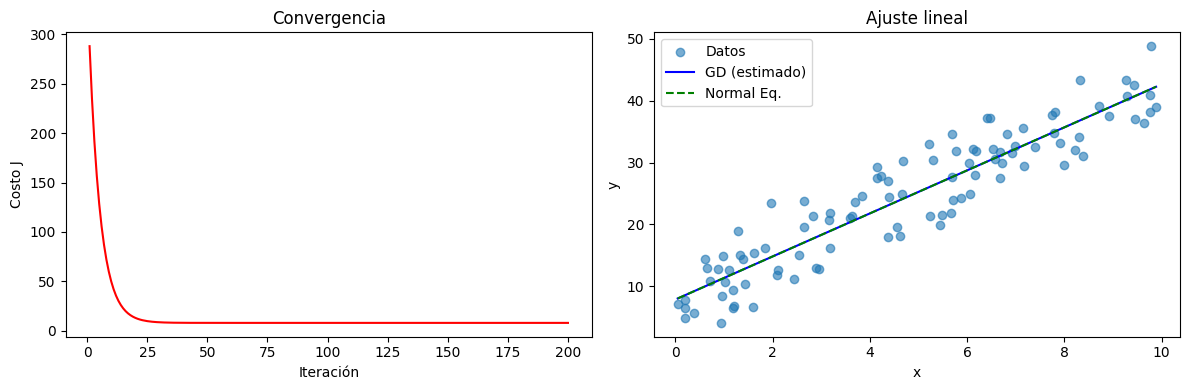

In [42]:

# 9) Plots: coste vs iteraciones y ajuste sobre los datos
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(np.arange(1, iters+1), J_hist, 'r-')
axes[0].set_xlabel('Iteración'); axes[0].set_ylabel('Costo J'); axes[0].set_title('Convergencia')

# Ajuste lineal sobre datos
x_line = np.linspace(x.min(), x.max(), 100)
y_pred_gd = theta0_orig + theta1_orig * x_line
y_pred_ne = theta_normal[0] + theta_normal[1] * x_line

axes[1].scatter(x, y, alpha=0.6, label='Datos')
axes[1].plot(x_line, y_pred_gd, 'b-', label='GD (estimado)')
axes[1].plot(x_line, y_pred_ne, 'g--', label='Normal Eq.')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].set_title('Ajuste lineal')
axes[1].legend()

plt.tight_layout()
plt.show()

## Ejemplo de descenso de gradiente con 3 variables

modelar una variable continua 
𝑦
y en función de tres variables independientes:
$$
𝑦 = 𝛽_0 +𝛽_1𝑥_1+𝛽_2𝑥_2+𝛽_3𝑥_3 +𝜀
$$

Ejemplo contextual :
- $𝑥_1$: horas de estudio
- $x_2$: número de clases asistidas
- $x_3$: nivel de experiencia previa
- $y$: puntaje final obtenido

El objetivo es estimar los coeficientes $β$ usando descenso de gradiente.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Número de observaciones
n = 200

# Variables independientes
X1 = np.random.uniform(0, 10, n)
X2 = np.random.uniform(0, 5, n)
X3 = np.random.uniform(0, 3, n)

# Coeficientes reales (desconocidos para el modelo)
beta_0 = 5
beta_1 = 2.0
beta_2 = -1.5
beta_3 = 3.0

# Variable dependiente con ruido
y = beta_0 + beta_1*X1 + beta_2*X2 + beta_3*X3 + np.random.normal(0, 2, n)

# DataFrame
df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "y": y
})

df.head()


,X1,X2,X3,y
0,3.745401,3.210158,0.309372,7.543165
1,9.507143,0.420700,2.707659,29.920467
2,7.319939,0.808144,1.515757,22.760874
3,5.986585,4.492771,2.479372,15.601646
4,1.560186,3.032145,0.960149,5.345303


In [44]:
# Incluimos el término de sesgo (bias) y normalizamos las variables para mejorar la convergencia.

# Matriz de features
X = df[["X1", "X2", "X3"]].values
y = df["y"].values.reshape(-1, 1)

# Normalización (muy importante para descenso de gradiente)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

# Agregar columna de 1s para el bias
X_b = np.c_[np.ones((n, 1)), X_norm]

X_b.shape
# cambiar x-B a dataframe para mejor visualización
pd.DataFrame(X_b, columns=["bias", "X1_norm", "X2_norm", "X3_norm"]).head()


,bias,X1_norm,X2_norm,X3_norm
0,1.0,-0.372140,0.470994,-1.362137
1,1.0,1.586615,-1.437843,1.245778
2,1.0,0.843056,-1.172714,-0.050305
3,1.0,0.389770,1.348691,0.997537
4,1.0,-1.115023,0.349180,-0.654477


**Funcion de costo**:
$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2
$$

**Simplificada para descenso de gradiente**:
$$
J(\boldsymbol{\theta}) = \frac{1}{2m}\sum_{i=1}^{m}(\mathbf{x} \boldsymbol{\theta} -y)^2
$$


In [45]:
# funcion de costo MSE
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    cost = (1 / (2*m)) * np.sum(errors**2)
    return cost


# implementacion de descenso de gradiente vectorizado
def gradient_descent(X, y, alpha=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    cost_history = []

    for epoch in range(epochs):
        gradients = (1/m) * X.T @ (X @ theta - y)
        theta = theta - alpha * gradients
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history


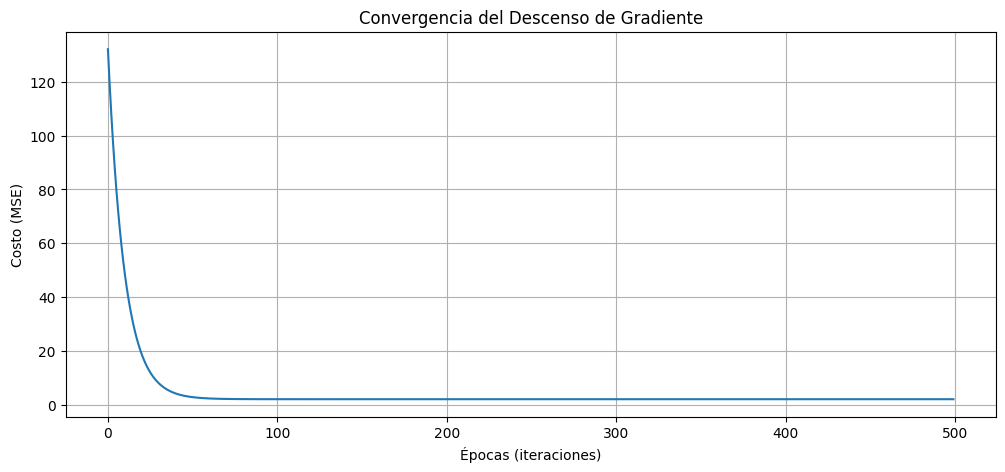

In [50]:
# entreamiento del modelo
theta, cost_history = gradient_descent(
    X_b, y,
    alpha=0.05, # tasa de aprendizaje
    epochs=500
)

theta

# Graficos de convergencia
plt.figure(figsize=(12, 5))
plt.plot(cost_history)
plt.xlabel("Épocas (iteraciones)")
plt.ylabel("Costo (MSE)")
plt.title("Convergencia del Descenso de Gradiente")
plt.grid(True)
plt.show()

# interpretacion de el grafico de convergencia:
# El costo disminuye rápidamente al inicio y luego se estabiliza, 
# indicando que el modelo está aprendiendo y convergiendo hacia una solución óptima.

In [51]:
# interpretacion de los coeficientes en el espacio original
# Los coeficientes están en escala normalizada. Los llevamos a la escala original:

beta_0_est = theta[0]
beta_rest = theta[1:].flatten() / X_std

beta_0_real = beta_0_est - np.sum((X_mean / X_std) * theta[1:].flatten())

beta_0_real, beta_rest


(array([4.88765214]), array([ 1.9910359 , -1.60089492,  3.18641678]))

Ejemplo contextual :
- $𝑥_1$: horas de estudio
- $x_2$: número de clases asistidas
- $x_3$: nivel de experiencia previa
- $y$: puntaje final obtenido

In [58]:
def predict(X_new, theta, X_mean, X_std):
    X_new_norm = (X_new - X_mean) / X_std
    X_new_b = np.c_[np.ones((X_new.shape[0], 1)), X_new_norm]
    return X_new_b @ theta

# Nuevo estudiante
X_new = np.array([[32, 9, 5]])

y_pred = predict(X_new, theta, X_mean, X_std)
y_pred


array([[70.12483069]])

### Como elegir una tasa de aprendizaje

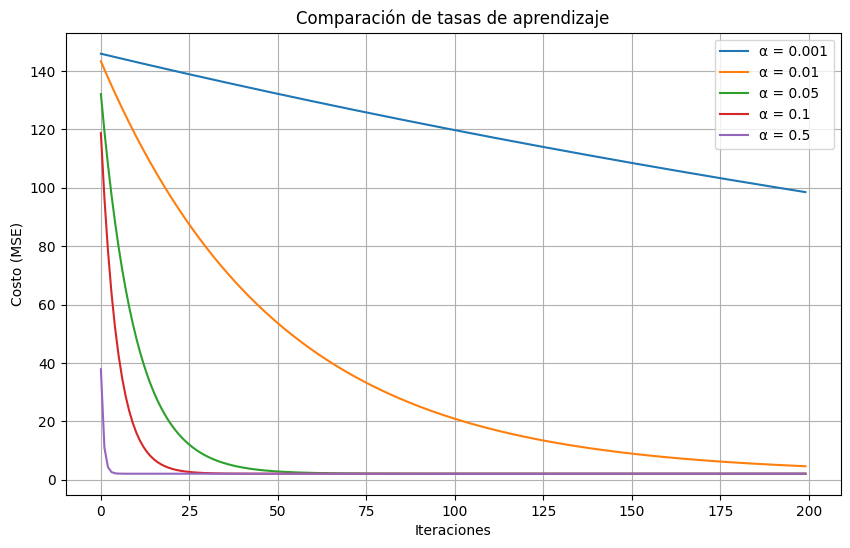

In [59]:

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
epochs = 200
cost_histories = {}

for lr in learning_rates:
    _, cost_history = gradient_descent(
        X_b, y,
        alpha=lr,
        epochs=epochs
    )
    cost_histories[lr] = cost_history

plt.figure(figsize=(10,6))

for lr, costs in cost_histories.items():
    plt.plot(costs, label=f"α = {lr}")

plt.xlabel("Iteraciones")
plt.ylabel("Costo (MSE)")
plt.title("Comparación de tasas de aprendizaje")
plt.legend()
plt.grid(True)
plt.show()


# ADAM


## 1️⃣ ¿Qué es Adam?

**Adam (Adaptive Moment Estimation)** es un algoritmo de optimización que extiende el descenso de gradiente combinando **dos ideas clave**:

1. **Momentum** → usa información histórica del gradiente
2. **Learning rate adaptativo** → ajusta automáticamente el tamaño del paso por parámetro

📌 En la práctica:

> **Adam es el optimizador por defecto en deep learning y ML moderno.**

---

## 2️⃣ Intuición (por qué funciona mejor)

Adam mantiene **dos promedios móviles** del gradiente:

* **Primer momento (media)** → dirección promedio
* **Segundo momento (varianza)** → magnitud / estabilidad

Esto permite:

* Avanzar rápido cuando el gradiente es consistente
* Reducir el paso cuando hay ruido u oscilaciones

![Image](https://machinelearningmastery.com/wp-content/uploads/2017/05/Comparison-of-Adam-to-Other-Optimization-Algorithms-Training-a-Multilayer-Perceptron.png?utm_source=chatgpt.com)

![Image](https://www.researchgate.net/publication/332715365/figure/fig2/AS%3A962461960241156%401606480221448/Adam-is-an-effective-gradient-descent-algorithm-for-ODEs-a-Using-a-constant-learning.png?utm_source=chatgpt.com)

![Image](https://i.sstatic.net/bWW3a.png?utm_source=chatgpt.com)

---

## 3️⃣ Formulación matemática (resumen operativo)

Para cada iteración ( t ):

1. Gradiente:
   $$
   g_t = \nabla J(\theta_t)
   $$

2. Momentos:
   $$
   m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
   $$
   $$
   v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
   $$

3. Corrección de sesgo:
   $$
   \hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad
   \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
   $$

4. Actualización:
   $$
   \theta_{t+1} = \theta_t - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
   $$

Valores estándar (industria):

* ( \alpha = 0.001 )
* ( \beta_1 = 0.9 )
* ( \beta_2 = 0.999 )
* ( \epsilon = 10^{-8} )

📌 **Estos rara vez se modifican**.

---

## 4️⃣ ¿Por qué Adam supera al GD clásico?

| Aspecto           | GD clásico | Adam         |
| ----------------- | ---------- | ------------ |
| Learning rate     | Fijo       | Adaptativo   |
| Sensible a escala | Sí         | No           |
| Oscilaciones      | Frecuentes | Amortiguadas |
| Convergencia      | Lenta      | Rápida       |
| Ajuste manual     | Alto       | Bajo         |

➡️ **Adam reduce drásticamente la necesidad de tuning**.

---

## 5️⃣ Implementación desde cero

´´´
def adam_optimizer(X, y, alpha=0.001, beta1=0.9, beta2=0.999, eps=1e-8, epochs=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    m_t = np.zeros_like(theta)
    v_t = np.zeros_like(theta)
    cost_history = []

    for t in range(1, epochs + 1):
        grad = (1/m) * X.T @ (X @ theta - y)

        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)

        theta -= alpha * m_hat / (np.sqrt(v_hat) + eps)

        cost = (1/(2*m)) * np.sum((X @ theta - y) ** 2)
        cost_history.append(cost)

    return theta, cost_history
´´´

## 6️⃣ Comparación empírica: GD vs Adam

```python
theta_gd, cost_gd = gradient_descent(X_b, y, alpha=0.05, epochs=500)
theta_adam, cost_adam = adam_optimizer(X_b, y, alpha=0.01, epochs=500)

plt.figure(figsize=(9,5))
plt.plot(cost_gd, label="Gradient Descent")
plt.plot(cost_adam, label="Adam")
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("GD vs Adam")
plt.legend()
plt.grid(True)
plt.show()
```

🔍 Observación típica:

* Adam **converge antes**
* Curva más suave
* Menor sensibilidad al learning rate

---

## 7️⃣ ¿Cuándo usar Adam en la práctica real?

✅ Usar Adam cuando:

* Dataset grande o ruidoso
* Features con distintas escalas
* Redes neuronales
* Entrenamiento continuo
* Prototipado rápido

⚠️ Considerar alternativas cuando:

* Dataset pequeño y bien condicionado → OLS
* Optimización convexa simple → GD clásico

---

## 8️⃣ Adam en librerías reales

```python
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    loss="squared_error",
    learning_rate="adaptive",
    eta0=0.01
)
```

```python
# Keras / TensorFlow
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
```

```python
# PyTorch
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
```

📌 **Adam es estándar industrial**.

---

## 9️⃣ Resumen ejecutivo

> **Adam es descenso de gradiente inteligente**.

* Aprende rápido
* Se adapta automáticamente
* Reduce tuning manual
* Base del deep learning moderno

Si hoy entrenas un modelo **y no sabes qué optimizador usar** → **Adam**.

---

Si quieres, puedo:

* mostrar **casos donde Adam falla**
* comparar **Adam vs RMSProp vs SGD**
* explicar **por qué Adam generaliza distinto**
* integrar Adam en un **notebook docente evaluable**

¿Avanzamos con alguno?
